# Исследование финансирования стартапов

## Введение

### Цели и задачи проекта

**Цель**

Исследовать исторические данные о финансировании стартапов, выявить закономерности привлечения инвестиций и на их основе сформулировать рекомендации по наиболее перспективным направлениям инвестирования.

**Задачи**

- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет — `cb_investments`

### Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### Содержимое проекта

1. Знакомство с данными: загрузка и предобработка
2. Инжиниринг признаков
3. Работа с выбросами и анализ
4. Анализ динамики
5. Итоговый вывод и рекомендации

### 1.1. Вывод общей информации


In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Настройки отображения колонок
pd.set_option('display.max_columns', None)
# Настройки размера графиков
plt.rcParams['figure.figsize'] = (15, 8)

In [2]:
cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [7]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [8]:
# Создание функции gaps которая определяет пропуски для датафреймов
def gaps(any_df):
    gaps_table = pd.DataFrame({
        'Количество пропусков': any_df.isnull().sum(),
        'Доля пропусков (%)': (any_df.isnull().mean() * 100).round(2),
        'Тип данных': any_df.dtypes})
    return gaps_table

In [9]:
# Выводим пропуски датафрейма 'cb_investments'
gaps(cb_investments)

,Количество пропусков,Доля пропусков (%),Тип данных
name,4857,8.95,object
homepage_url,8305,15.30,object
category_list,8817,16.24,object
market,8817,16.24,object
funding_total_usd,4856,8.94,object
status,6170,11.36,object
country_code,10129,18.66,object
state_code,24133,44.45,object
region,10129,18.66,object
city,10972,20.21,object


In [10]:
# Выводим пропуски датафрейма 'cb_returns'
gaps(cb_returns)

,Количество пропусков,Доля пропусков (%),Тип данных
year,0,0.0,int64
seed,0,0.0,float64
venture,0,0.0,float64
equity_crowdfunding,0,0.0,float64
undisclosed,0,0.0,float64
convertible_note,0,0.0,float64
debt_financing,0,0.0,float64
angel,0,0.0,float64
grant,0,0.0,float64
private_equity,0,0.0,float64


In [11]:
# Выводим дубликаты явные дубликаты из двух датафреймов

# Сохдаем словарь для создания цикла
dataframes = {'cb_investments': cb_investments,
              'cb_returns' : cb_returns}
# Делаем цикл
for name, any_df in dataframes.items():
    print(f'Количество пропусков в датафреме {name}')
    print(any_df.duplicated().sum()) 

Количество пропусков в датафреме cb_investments
4855
Количество пропусков в датафреме cb_returns
0


### Вывод по знакомству с данными

В ходе знакомства с данными были изучены две таблицы: `cb_investments`, содержащая информацию о 54 294 компаниях и их финансировании, и `cb_returns`, включающая сведения о возврате инвестиций по 15 годам. Структура и состав признаков соответствуют описанию проекта.

В таблице `cb_investments` выявлены следующие особенности, требующие внимания на этапе предобработки:

* **Пропущенные значения** обнаружены в большинстве признаков. Наибольшая доля пропусков наблюдается в столбцах:

  * `state_code` — 44,45%;
  * `participants` — 43,87%;
  * `mid_funding_at` — 44,21%;
  * `founded_at`, `founded_month`, `founded_quarter`, `founded_year` — около 29%;
  * `country_code`, `region`, `city`, `category_list`, `market` — от 16% до 20%.

* **Некорректные типы данных** выявлены в следующих столбцах:

  * `funding_total_usd` — хранится в типе `object`, хотя представляет собой числовой показатель;
  * `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` — содержат даты, но имеют тип `object`;
  * `founded_year` — хранится в типе `float64`, хотя представляет собой год основания компании.

* **Явные дубликаты** обнаружены только в таблице `cb_investments` — 4 855 строк, что требует дополнительной проверки перед их удалением.

Таблица `cb_returns` не содержит пропущенных значений и явных дубликатов. Типы данных соответствуют содержимому признаков и не требуют изменения.

Таким образом, основное внимание на этапе предобработки будет уделено таблице `cb_investments`: проверке и обработке пропусков, приведению типов данных к корректному виду, а также анализу и обработке обнаруженных дубликатов.


### 1.2. Предобработка данных

In [12]:
# Выводим колонки датафреймов

# Сохдаем словарь для создания цикла
dataframes = {'cb_investments': cb_investments,
              'cb_returns' : cb_returns}
# Делаем цикл
for name, column in dataframes.items():
    print()
    print(f'Датафрейм {name}')
    print()
    print(column.columns)
    print()


Датафрейм cb_investments

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')


Датафрейм cb_returns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')



In [13]:
# Убираем пробелы в колонках датафрейма 'cb_investments'
cb_investments.columns = cb_investments.columns.str.strip()

In [14]:
# Проверяем результат колонок в датафрейме 'cb_investments'
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

**Вывод по названию столбцов**

Названия столбцов были проверены на соответствие содержимому и единому стилю оформления. Было обнаружено, что два столбца (`market` и `funding_total_usd`) содержали лишние пробелы в начале и конце названия. Пробелы были удалены с помощью метода str.strip(), после чего все названия столбцов приведены к единому и удобному для работы стилю. Других несоответствий в именах столбцов обнаружено не было.

Убираем в столбце `funding_total_usd` выделение разрядов и приведим его к числовому типу.

In [15]:
# Столбец 'funding_total_usd' переводим в числовой формат float64 и убираем запятые, 
# переводим в Nan строки которые не смогли перейти в тип float64 
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'].str.replace(',', ''), errors='coerce')

In [16]:
# Выводим результат
cb_investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

In [17]:
# Проверяем пропуски
cb_investments['funding_total_usd'].isna().sum()

13387

**Вывод по обработке столбца `funding_total_usd`**

В столбце `funding_total_usd` значения были записаны в строковом формате с разделителями разрядов, что не позволяло выполнять числовые расчёты. Запятые были удалены, после чего столбец преобразован к числовому типу с помощью `pd.to_numeric()`. В результате количество пропусков увеличилось до 13 387, поскольку некорректные значения, которые не удалось преобразовать в числовой формат, были автоматически заменены на NaN. Это позволило привести данные к единому формату и подготовить столбец к дальнейшему анализу.

Обработываем типы данных в столбцах, которые хранят значения даты и времени

In [18]:
# Выводим все столбцы с датами
columns_date = ['founded_at', 'founded_month', 
                'founded_quarter', 'founded_year', 
                'first_funding_at', 'mid_funding_at','last_funding_at']
cb_investments[columns_date].head()

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06
1,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15
2,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14


In [19]:
# Выводим столбцы 'founded_month', 'founded_quarter' без Nan
cb_investments[['founded_month', 'founded_quarter']].dropna().head()

,founded_month,founded_quarter
72,1902-01,1902-Q1
73,1902-01,1902-Q1
74,1903-01,1903-Q1
75,1905-01,1905-Q1
76,1906-01,1906-Q1


In [20]:
# переводим колонки 'columns' в тип datetime64
columns_datetime = ['founded_at','first_funding_at', 'mid_funding_at','last_funding_at']
cb_investments[columns_datetime ] = cb_investments[columns_datetime].apply(pd.to_datetime, errors = 'coerce')

In [21]:
# Переводим столбец 'founded_year' в тип Int64
cb_investments['founded_year'] = cb_investments['founded_year'].astype('Int16')

In [22]:
# Выводим датаврейм с результатом дат
cb_investments[columns_date].head()

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,NaT,NaN,NaN,1636,2014-01-06,NaT,2014-01-06
1,1785-01-01,NaN,NaN,1785,2014-05-15,NaT,2014-05-15
2,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaN,NaN,1817,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaN,NaN,1826,2014-01-14,NaT,2014-01-14


In [23]:
# Проверяем тип данных в колонках с датами
cb_investments[columns_date].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   founded_month     38482 non-null  object        
 2   founded_quarter   38482 non-null  object        
 3   founded_year      38554 non-null  Int16         
 4   first_funding_at  49428 non-null  datetime64[ns]
 5   mid_funding_at    30288 non-null  datetime64[ns]
 6   last_funding_at   49432 non-null  datetime64[ns]
dtypes: Int16(1), datetime64[ns](4), object(2)
memory usage: 2.6+ MB


**Вывод по переводу типа данных столбцов с датами** 

Столбцы, содержащие полные даты (`founded_at, first_funding_at, mid_funding_at и last_funding_at`), были преобразованы к типу `datetime64`, что позволит выполнять операции с датами и рассчитывать временные интервалы. Столбец founded_year был преобразован к целочисленному типу `Int64`, так как содержит только год основания компании. Столбцы `founded_month` и `founded_quarter` оставлены без изменений, поскольку содержат месяц и квартал основания, а не полную календарную дату, и их текущий формат соответствует описанию данных.

В датасете `cb_returns` делаем столбец `year` индексом всего датасета

In [24]:
# Меняем индекс на 'year'
cb_returns = cb_returns.set_index('year')
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


**Вывод по индекс `year`в датасете `cb_returns`**

В датасете cb_returns столбец year был установлен в качестве индекса, так как каждая строка соответствует отдельному году. Это делает структуру таблицы более логичной и упрощает дальнейшую работу с временными данными, включая выборку и анализ по годам.

Обработываем текстовые данные. Пропуски в текстовых столбцах заполняем заглушками.

In [25]:
# Выводим колонки с пропусками типа данных 'object
gaps_column = gaps(cb_investments)
gaps_column.loc[gaps_column['Тип данных']== 'object']

,Количество пропусков,Доля пропусков (%),Тип данных
name,4857,8.95,object
homepage_url,8305,15.30,object
category_list,8817,16.24,object
market,8817,16.24,object
status,6170,11.36,object
country_code,10129,18.66,object
state_code,24133,44.45,object
region,10129,18.66,object
city,10972,20.21,object
founded_month,15812,29.12,object


In [26]:
# Вставляем заглушки в пропуски для категориальных столбцов 'category_list', 'market', 'status' == 'No data'
for column in['category_list', 'market', 'status']:
    cb_investments[column] = cb_investments[column].fillna('No data') 
cb_investments[['category_list', 'market', 'status']].head()

,category_list,market,status
0,|Education|,Education,operating
1,No data,No data,operating
2,|Business Services|Agriculture|Automotive|Inve...,Business Services,operating
3,|Education|,Education,operating
4,|Education|,Education,operating


**Вывод по обработке текстовых столбцов**

В текстовых столбцах были проанализированы пропущенные значения. Заглушкой `No data` были заполнены пропуски только в столбцах `category_list`, `market` и `status`, поскольку отсутствие этих значений можно интерпретировать как неизвестную категорию, рынок или статус компании. Пропуски в остальных текстовых столбцах оставлены без изменений, так как их корректное восстановление невозможно, а использование заглушек могло бы исказить результаты дальнейшего анализа.

Обработываем полные дубликаты в данных и пропуски в `funding_total_usd`.

In [27]:
# Всего строк в датафрейме 'cb_investments'
shape_0 = cb_investments.shape[0]
shape_0

54294

In [28]:
# Полные дубликаты в даафрейме 'cb_investments'
cb_investments.duplicated().sum()

4855

In [29]:
# Количество пропусков в 'funding_total_usd'
cb_investments['funding_total_usd'].isna().sum()

13387

In [30]:
# Удоляем полные дубликаты 
cb_investments = cb_investments.drop_duplicates()

In [31]:
# Итого полных дубликатов 
cb_investments.duplicated().sum()

0

In [32]:
# Общее количество строк после удаления полных дубликатов 
cb_investments.shape[0]

49439

In [33]:
# Количество пустых строк в столбце 'funding_total_usd'
cb_investments['funding_total_usd'].isna().sum()

8532

In [34]:
# Удаление строк с пропусками в столбце 'funding_total_usd'
cb_investments = cb_investments.dropna(subset = ['funding_total_usd'])

In [35]:
# Итого пропусков в столбце 'funding_total_usd'
cb_investments['funding_total_usd'].isna().sum()

0

In [36]:
# Общее количество строк после удаления строк полных дубликатов и строк с пропусками в столбце 'funding_total_usd'
shape_1 = cb_investments.shape[0]
shape_1

40907

**Вывод по удолению полных дубликатов и строк спропусками в столбце 'funding_total_usd'**

В датафрейме было обнаружено 4855 полных дубликатов, которые были удалены. Также удалены 13387 строк с пропусками в столбце funding_total_usd, поскольку они не содержат информации об общем объёме финансирования и не могут быть использованы в дальнейшем анализе. В результате количество строк сократилось с 54294 до 40907.

Заполняем пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков заносим приблизительно середину интервала между этими двумя датами.

In [37]:
# Выводим столбцы 'first_funding_at', 'last_funding_at', 'mid_funding_at'
cb_investments[['first_funding_at', 'last_funding_at', 'mid_funding_at']].head()

,first_funding_at,last_funding_at,mid_funding_at
0,2014-01-06,2014-01-06,NaT
1,2014-05-15,2014-05-15,NaT
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2014-11-03,2013-11-21
4,2014-01-14,2014-01-14,NaT


In [38]:
# Создаем формулу
mid = cb_investments['first_funding_at'] + (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2
# Заполняем средним интервалом
cb_investments.loc[cb_investments['mid_funding_at'].isna(),'mid_funding_at'] = mid

In [39]:
# Выводим результат
print(cb_investments[['first_funding_at', 'last_funding_at', 'mid_funding_at']].head())
print()
print(f"Количество оставшихся просусков в столбце 'mid_funding_at': {cb_investments['mid_funding_at'].isna().sum()}")

  first_funding_at last_funding_at mid_funding_at
0       2014-01-06      2014-01-06     2014-01-06
1       2014-05-15      2014-05-15     2014-05-15
2       2009-07-02      2009-07-02     2009-07-02
3       2013-11-21      2014-11-03     2013-11-21
4       2014-01-14      2014-01-14     2014-01-14

Количество оставшихся просусков в столбце 'mid_funding_at': 1


**Вывод по заполненым пропускам в столбце `mid_funding_at`**

Пропуски в столбце `mid_funding_at` были заполнены с использованием приблизительной середины интервала между датами первого `first_funding_at` и последнего `last_funding_at` раундов финансирования. Такой подход позволил восстановить большую часть отсутствующих значений, сохранив логическую последовательность временных данных. После обработки в столбце остался **1 пропуск**, который не удалось заполнить из-за отсутствия даты первого раунда финансирования `first_funding_at`, необходимой для вычисления середины интервала. Это единичное значение не оказывает существенного влияния на дальнейший анализ и было оставлено без изменений.

Оцениваем полноту данных

In [40]:
print(f'Количество строк в начале обработки данных: {shape_0}')
print(f'Количество строк в конце обработки данных: {shape_1}')
print(f'Количество удаленных строк: {shape_0 - shape_1}')
print(f'Процент удаленных строк: {round(100 - shape_1 / shape_0 *100, 2)} %')

Количество строк в начале обработки данных: 54294
Количество строк в конце обработки данных: 40907
Количество удаленных строк: 13387
Процент удаленных строк: 24.66 %


**Вывод по удаленным данным и их полноте для решения задач проекта**

В ходе предобработки были удалены полные дубликаты и строки, не содержащие информации об общем объёме финансирования `funding_total_usd`. В результате было отброшено **24,66%** исходных данных, а в датасете осталось **40 907** наблюдений из **54 294**. Несмотря на сокращение объёма выборки, оставшееся количество данных является достаточным для проведения дальнейшего анализа и решения поставленных в проекте задач, поскольку включает значительный объём информации о финансировании стартапов.

### Вывод по предобработке данных

В ходе предобработки данные были приведены к удобному для анализа виду. Были исправлены названия столбцов, обработаны типы данных, преобразованы числовые и временные признаки, заполнены часть пропусков в категориальных столбцах, удалены полные дубликаты и строки без информации об общем объёме финансирования. Также были восстановлены пропущенные значения в столбце `mid_funding_at`, где это было возможно. Несмотря на удаление части данных, итоговый датасет сохранил достаточный объём наблюдений и готов к проведению исследовательского анализа

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделяем все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

In [41]:
# Создаем функцию 'get_group' которая делает условное выражение
def get_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif (row['last_funding_at'] - row['first_funding_at']).days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'
# Создаем новый столбец и применяем функцию 'get_group' через 'apply'
cb_investments['funding_group'] = cb_investments.apply(get_group, axis = 1)

In [42]:
cb_investments[['funding_rounds','first_funding_at','last_funding_at','funding_group']].head()

,funding_rounds,first_funding_at,last_funding_at,funding_group
0,1.0,2014-01-06,2014-01-06,Единичное финансирование
1,1.0,2014-05-15,2014-05-15,Единичное финансирование
2,1.0,2009-07-02,2009-07-02,Единичное финансирование
3,3.0,2013-11-21,2014-11-03,Срок финансирования до года
4,1.0,2014-01-14,2014-01-14,Единичное финансирование


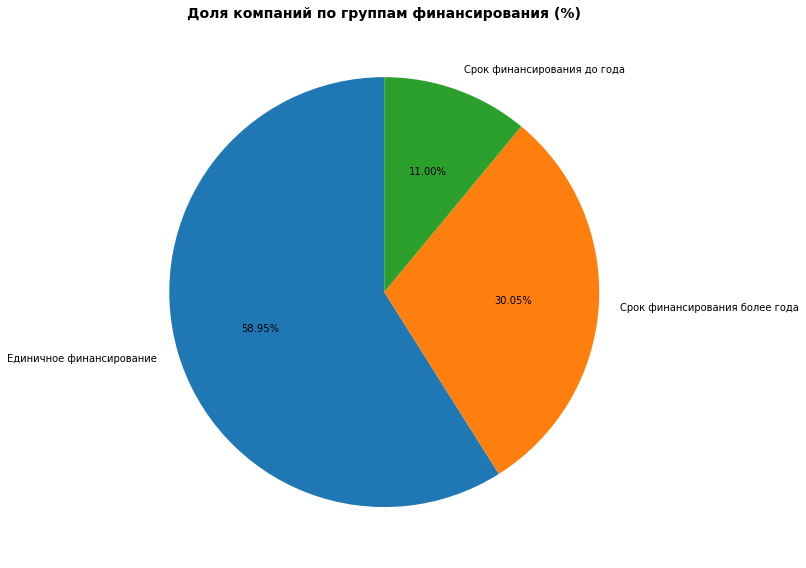

In [43]:
# Задаем порядок цветов ячеек
colors = ['tab:blue', 'tab:orange', 'tab:green']
# задаем порядок названий
order = ['Единичное финансирование','Срок финансирования до года','Срок финансирования более года']
# Строим круговой график
(cb_investments['funding_group'].value_counts(normalize=True)*100).round(2).plot(kind = 'pie', 
                                                                                 autopct='%1.2f%%', 
                                                                                 ylabel='', 
                                                                                 startangle=90,
                                                                                 colors = colors)
                                                                                 
# Задаем заголовок
plt.title('Доля компаний по группам финансирования (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

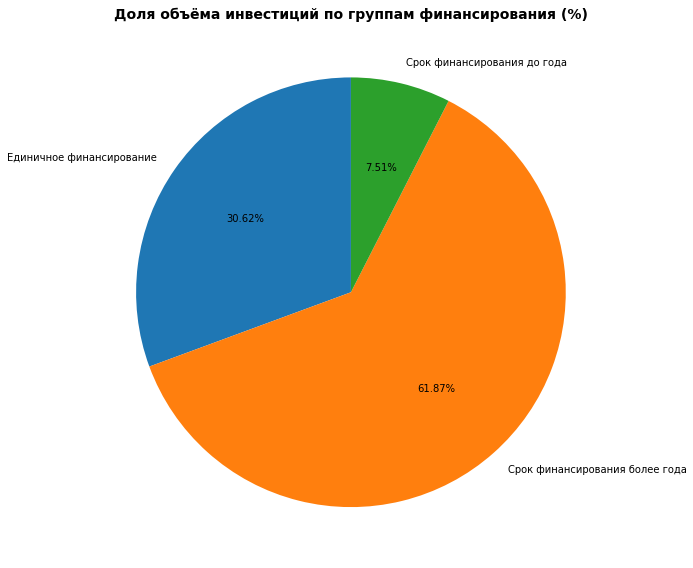

In [44]:
# Создаем группу по 'funding_group' и сумме 'funding_total_usd' 
investment = cb_investments.groupby('funding_group')['funding_total_usd'].sum()
# Делаем деление
investment_percentage = (investment / investment.sum() * 100).round(2).plot(kind = 'pie', 
                                                                                 autopct='%1.2f%%', 
                                                                                 ylabel='', 
                                                                                 startangle=90,
                                                                                 colors = colors)
# Задаем заголовок
plt.title('Доля объёма инвестиций по группам финансирования (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Вывод по по количеству компаний: процент от общего числа компаний относится к каждой из трёх групп.
по объёму инвестиций: доля от общего объёма привлечённых средств получила каждая группа.**

Компании были разделены на три группы в зависимости от срока финансирования. Наибольшая доля компаний (58,95%) получила только один раунд финансирования, тогда как 30,05% компаний привлекали инвестиции более года, а 11,00% — в течение одного года. При этом по объёму инвестиций лидируют компании со сроком финансирования более года, на которые приходится 61,87% всех привлечённых средств. Компании с единичным финансированием, несмотря на их численное преобладание, привлекли лишь 30,62% общего объёма инвестиций, а компании со сроком финансирования до года — всего 7,51%. Это может свидетельствовать о том, что компании, успешно проходящие несколько раундов финансирования, вызывают больше доверия у инвесторов и со временем привлекают значительно больший объём капитала.

### 2.2 Выделение средних и нишевых сегментов рынка


Создаем отдельный столбец с категриями:

болше 120 - массовый

от 35 до 120 включительно - средний

до 35 - нишевой


In [45]:
# Делаем распределение по сегментам и добавляем категории
market_quantity = cb_investments['market'].value_counts().reset_index()
market_quantity.columns = ['market', 'quantity']
market_quantity['market_category'] = pd.cut(market_quantity['quantity'],
                                 bins =[0, 35, 121, float('inf')], labels =['Нишевый','Средний','Массовый'], right=False)
market_quantity

,market,quantity,market_category
0,Software,4190,Массовый
1,Biotechnology,3531,Массовый
2,No data,2503,Массовый
3,Mobile,1852,Массовый
4,E-Commerce,1528,Массовый
...,...,...,...
844,Flash Storage,1,Нишевый
845,Crowdfunding,1,Нишевый
846,Consumer Internet,1,Нишевый
847,Networking,1,Нишевый


In [46]:
# Делаем распределение по категориям
market_quantity_category = market_quantity['market_category'].value_counts().reset_index()
market_quantity_category.columns = ['market_category','count_categoty']
market_quantity_category

,market_category,count_categoty
0,Нишевый,714
1,Средний,81
2,Массовый,54


In [47]:
# Создаем словарь из 'market_quantity'
market_dict = market_quantity.set_index('market')['market_category']
# Создаем столбец 'market_category' в датафрейме 'cb_investments' и присоденеяем значения словаря 'market_dict' по столбцу 'market'
cb_investments['market_category'] = cb_investments['market'].map(market_dict)
# Переводим 'market_category' в тип 'object' и заменяем Nan на 'Нет категории'
cb_investments['market_category'] = cb_investments['market_category'].astype('object').fillna('Нет категории')
# Выводим итоговый 'датафрейм'
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_group,market_category
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,1.0,NaN,NaT,NaN,NaN,1636,2014-01-06,2014-01-06,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый
1,University of New Brunswick,http://www.unb.ca,No data,No data,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средний
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовый
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый


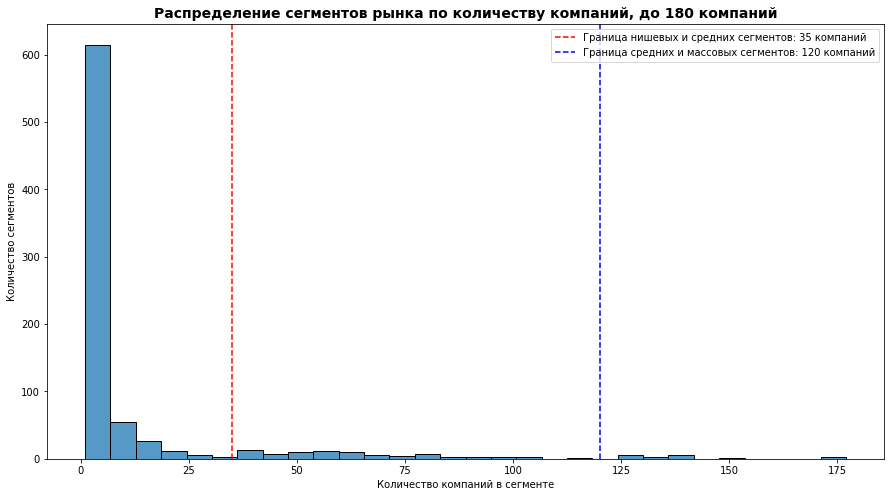

In [48]:
# Создаем график распредения график распределения количества компаний в сегментах
sns.histplot(data = market_quantity[market_quantity['quantity'] <=180], x ='quantity', bins = 30)

plt.axvline(35, color ='red',linestyle ='--', label ='Граница нишевых и средних сегментов: 35 компаний')

plt.axvline(120, color='blue', linestyle='--',label='Граница средних и массовых сегментов: 120 компаний')

plt.title('Распределение сегментов рынка по количеству компаний, до 180 компаний', fontsize=14, fontweight='bold')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()

plt.show()

Оставляем в столбце `market` только массовые сегменты. Для остальных сегментов заменяем значения на заглушки — `niche` для нишевых и `mid` для средних.

In [49]:
# Сохранием оригинал столбца 'market'
cb_investments['market_original'] = cb_investments['market']

In [50]:
# Присваеваем заглушки в столбец 'market'
cb_investments.loc[cb_investments['market_category'] == 'Средний', 'market'] = 'mid'
cb_investments.loc[cb_investments['market_category'] == 'Нишевый', 'market'] = 'niche'

In [51]:
# Проверяем результат
cb_investments[cb_investments['market'].isin(['niche', 'mid'])].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_group,market_category,market_original
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средний,Business Services
12,Siemens,http://www.siemens.com,|Clean Energy|Automotive|Hardware + Software|,niche,8900000.0,operating,DEU,NaN,Munich,Munich,1.0,1.0,1847-01-01,NaN,NaN,1847,2010-07-19,2010-07-19,2010-07-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8900000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевый,Hardware + Software
28,Independent Bank,http://independentbank.com,|Banking|Finance|,niche,13400000.0,operating,USA,TX,Dallas,Mckinney,1.0,0.0,1864-01-01,NaN,NaN,1864,2013-09-10,2013-09-10,2013-09-10,0.0,13400000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевый,Finance
42,CESC,https://www.cesc.co.in/,|Utilities|,niche,80000000.0,operating,IND,NaN,Kolkata,Kolkata,1.0,NaN,1879-07-24,NaN,NaN,1879,2014-10-29,2014-10-29,2014-10-29,0.0,80000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевый,Utilities
50,Arizona State University,http://www.asu.edu/,|Nonprofits|Universities|Education|,niche,1000000.0,operating,USA,AZ,Phoenix,Tempe,1.0,NaN,1885-02-26,NaN,NaN,1885,2014-02-13,2014-02-13,2014-02-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевый,Education


**Вывод по распределению количества компаний в сегментах**

Исходя из полученных данных, большая часть компаний относится к нишевым сегментам рынка. Средние сегменты представлены значительно меньшим количеством компаний, а массовые встречаются реже всего. Это может свидетельствовать о том, что большинство компаний работает в узкоспециализированных направлениях, тогда как лишь небольшая часть рынков становится массовой и объединяет большое количество участников. Для упрощения дальнейшего анализа нишевые и средние сегменты были объединены в категории niche и mid, а массовые сегменты сохранены без изменений. Это позволило сократить количество уникальных категорий и сделать последующий анализ более удобным и информативным.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов


По предобработанному столбцу `funding_total_usd` оцениваем размер общего финансирования будет стандартным, а какие выходят за рамки.

Определяем компании с аномальным объёмом общего финансирования через мето  IQR.

In [52]:
# Выводим распределение
cb_investments['funding_total_usd'].describe().apply('{:,.2f}'.format)

count            40,907.00
mean         15,912,526.05
std         168,678,800.17
min                   1.00
25%             350,000.00
50%           2,000,000.00
75%          10,000,000.00
max      30,079,503,000.00
Name: funding_total_usd, dtype: object

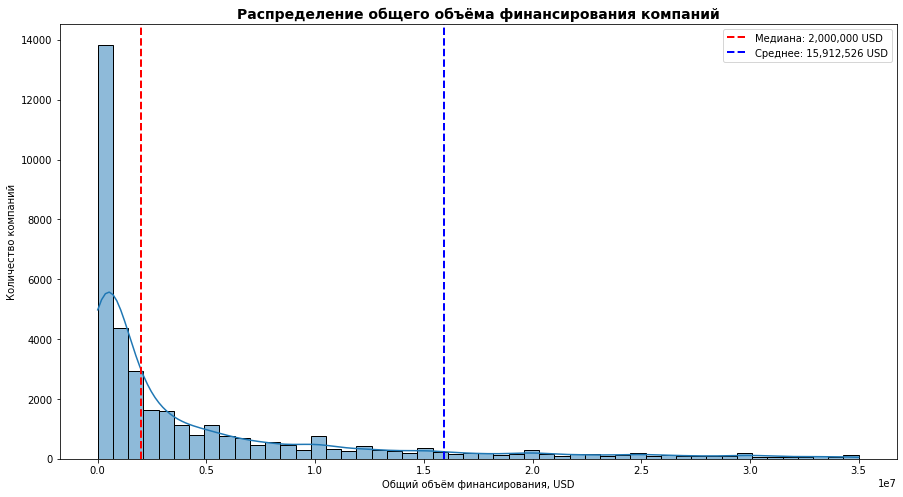

In [53]:
# Строим гистограму распределений 
sns.histplot(data=cb_investments[cb_investments['funding_total_usd'] <= 35000000],
             x='funding_total_usd',
             bins=50,
             kde=True)
# Добавляем медиану
median_usd = cb_investments['funding_total_usd'].median()
plt.axvline(median_usd, color = 'red', linestyle = '--', linewidth = 2, 
            label=f'Медиана: {median_usd:,.0f} USD')
# Добавляем среднее
mean_usd = cb_investments['funding_total_usd'].mean()
plt.axvline(mean_usd, color = 'blue', linestyle = '--', linewidth = 2, 
            label=f'Среднее: {mean_usd:,.0f} USD')
# Добавляем парметры
plt.title('Распределение общего объёма финансирования компаний', fontsize=14, fontweight='bold')
plt.xlabel('Общий объём финансирования, USD')
plt.ylabel('Количество компаний')
plt.legend()
plt.show()

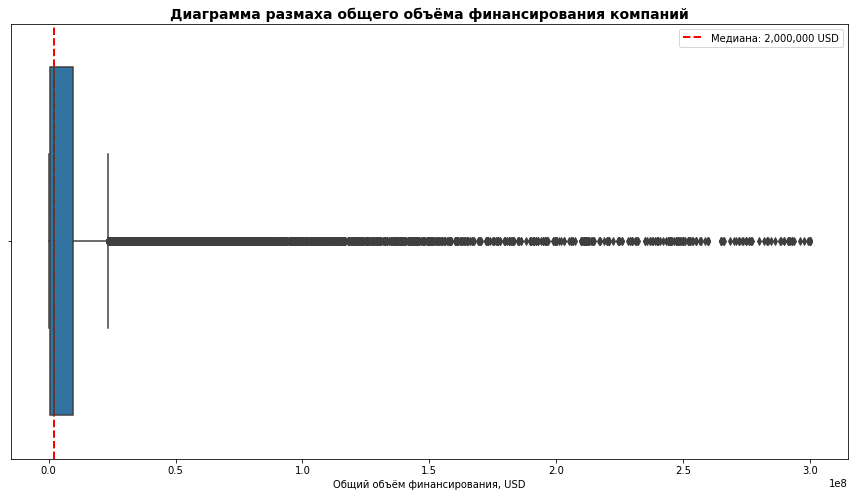

In [54]:
# Создаем переменную
total_usd = cb_investments[cb_investments['funding_total_usd'] <= 300000000]

# Создаем график ящик с усами
sns.boxplot(data=total_usd, 
            x='funding_total_usd')
# Добавляем медиану
median_usd = total_usd['funding_total_usd'].median()
plt.axvline(median_usd, color='red', linestyle='--', linewidth=2, 
            label=f'Медиана: {median_usd:,.0f} USD')

# Добавляем парметры
plt.title('Диаграмма размаха общего объёма финансирования компаний',fontsize=14,fontweight='bold')
plt.xlabel('Общий объём финансирования, USD')
plt.legend()
plt.show()

In [55]:
# Определяем типичное финансирование и выбивающиеся
Q1 = cb_investments['funding_total_usd'].quantile(0.25)
Q3 = cb_investments['funding_total_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Типичный интервал финансирования: от {Q1:,.0f} до {Q3:,.0f} USD')
print(f'Размах типичного интервала : {IQR:,.0f} USD')
print(f'Выбивающиеся значения финансирования: выше {upper_bound:,.0f} USD (верхняя граница IQR)')

Типичный интервал финансирования: от 350,000 до 10,000,000 USD
Размах типичного интервала : 9,650,000 USD
Выбивающиеся значения финансирования: выше 24,475,000 USD (верхняя граница IQR)


In [56]:
# Рассчитываем IQR отдельно для каждого сегмента
market_iqr = cb_investments.groupby('market')['funding_total_usd'].agg(
    q1 = lambda x: x.quantile(0.25),
    q3 = lambda x: x.quantile(0.75)).reset_index()

market_iqr['iqr'] = market_iqr['q3'] - market_iqr['q1']
market_iqr['lower_bound'] = market_iqr['q1'] - 1.5 * market_iqr['iqr']
market_iqr['upper_bound'] = market_iqr['q3'] + 2 * market_iqr['iqr']

# выводим результат
market_iqr.head(10)         

,market,q1,q3,iqr,lower_bound,upper_bound
0,Advertising,574126.25,12000000.0,11425873.75,-1.656468e+07,34851747.5
1,Analytics,500000.00,11700000.0,11200000.00,-1.630000e+07,34100000.0
2,Apps,98696.50,2184787.5,2086091.00,-3.030440e+06,6356969.5
3,Automotive,268888.75,10000000.0,9731111.25,-1.432778e+07,29462222.5
4,Big Data,300000.00,7000000.0,6700000.00,-9.750000e+06,20400000.0
5,Biotechnology,1500000.00,21975354.0,20475354.00,-2.921303e+07,62926062.0
6,Clean Technology,1500000.00,27890637.0,26390637.00,-3.808596e+07,80671911.0
7,Cloud Computing,600000.00,10000000.0,9400000.00,-1.350000e+07,28800000.0
8,Consulting,142750.00,6255000.0,6112250.00,-9.025625e+06,18479500.0
9,Curated Web,200000.00,4700000.0,4500000.00,-6.550000e+06,13700000.0


In [57]:
# Присоединяем upper_bound к основной таблице
cb_investments = cb_investments.merge(market_iqr[['market', 'upper_bound']], on='market', how='left')
# Создаем столбец-флаг: True, если компания получила аномально много денег
cb_investments['anomaly_flag'] = cb_investments['funding_total_usd'] > cb_investments['upper_bound']
# выводим результат
cb_investments[['market', 'funding_total_usd', 'upper_bound', 'anomaly_flag']].head()

,market,funding_total_usd,upper_bound,anomaly_flag
0,Education,90000000.0,15612084.5,True
1,No data,2000000.0,6491024.0,False
2,mid,9000000.0,22633000.0,False
3,Education,7700000.0,15612084.5,False
4,Education,540000.0,15612084.5,False


In [58]:
# Находим долю аномалий через столбец 'is_outlier'
percent_anomalies = (cb_investments.groupby('market')['anomaly_flag'].mean()*100).round(2).sort_values(ascending=False)
# Выводим топ 10 сегментов с анаомальными значениями
percent_anomalies.reset_index().head(10)

,market,anomaly_flag
0,Real Estate,17.13
1,Technology,14.85
2,E-Commerce,14.73
3,Internet,14.29
4,Search,14.05
5,Entertainment,13.87
6,SaaS,13.84
7,Marketplaces,13.64
8,Video,13.56
9,Consulting,13.35


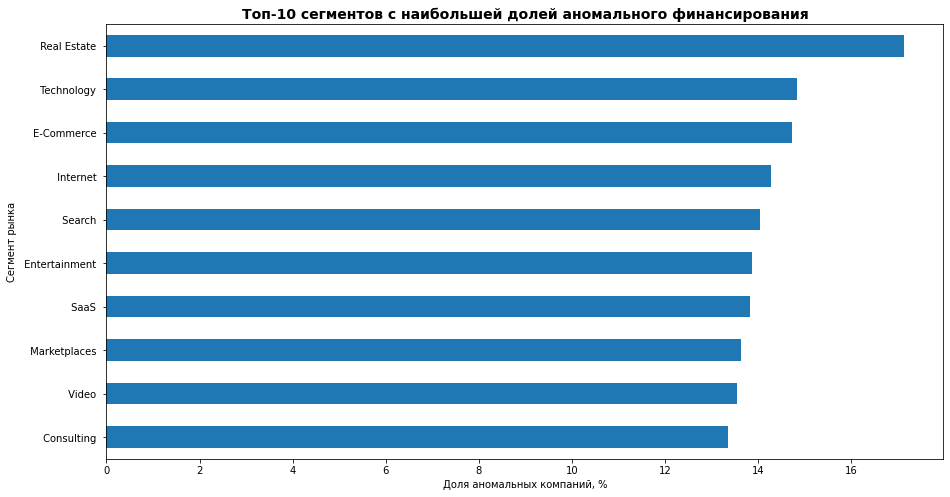

In [59]:
# Строем график Топ-10 сегментов с наибольшей долей аномального финансирования
percent_anomalies.head(10).sort_values(ascending= True).plot(kind='barh')

plt.title('Топ-10 сегментов с наибольшей долей аномального финансирования', fontsize=14,fontweight='bold')
plt.xlabel('Доля аномальных компаний, %')
plt.ylabel('Сегмент рынка')
plt.show()

**Вывод по топ-10 сегментов с наибольшей долей аномального финансирования**

Типичный объем финансирования для одной компании составляет `от 350 тыс. до 10 млн USD`. Глобальные выбросы `(выше 24,5 млн USD)` были определены методом IQR. Однако более корректным является сегментный подход, так как в разных отраслях свои масштабы инвестиций. После расчета IQR отдельно для каждого сегмента выявлено, что наибольшая доля аномалий приходится на `Real Estate (17.93%)`, `Technology (16.16%)` и `Search (16.12%)`. Это может объясняться наличием в этих сегментах единичных компаний с очень крупными раундами, сильно выделяющимися на фоне основной массы.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии
Проверяем по датасету, что данные за 2014 год полные.

Исключаем компании с аномальными значениями.

На основе столбцов `mid_funding_at` и `funding_rounds` оставляем в датасете данные только  о компаниях которые которые получили  50 или более раундов финансирования.

In [60]:
# Создаем столбец 'funding_year' из столбца 'mid_funding_at'
cb_investments['funding_year'] = cb_investments['mid_funding_at'].dt.year.astype('Int64')
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_group,market_category,market_original,upper_bound,anomaly_flag,funding_year
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,1.0,NaN,NaT,NaN,NaN,1636,2014-01-06,2014-01-06,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый,Education,15612084.5,True,2014
1,University of New Brunswick,http://www.unb.ca,No data,No data,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый,No data,6491024.0,False,2014
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средний,Business Services,22633000.0,False,2009
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовый,Education,15612084.5,False,2013
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый,Education,15612084.5,False,2014


In [61]:
# Создаем столбец 'year_month' где выделяем год и месяц 
cb_investments['year_month'] = cb_investments['mid_funding_at'].dt.strftime('%Y-%m')

# Группируем данные по 'year_month' и считаем сумму раундов
rounds_month = cb_investments.groupby('year_month')['funding_rounds'].count().reset_index()
rounds_month.columns = ['year_month', 'rounds_count']
rounds_2013_2014 = rounds_month[rounds_month['year_month'].str.startswith(('2013', '2014'))]
rounds_2013_2014

,year_month,rounds_count
209,2013-01,730
210,2013-02,520
211,2013-03,653
212,2013-04,642
213,2013-05,633
214,2013-06,734
215,2013-07,754
216,2013-08,775
217,2013-09,780
218,2013-10,783


In [62]:
# Оставляем строки где 'anomaly_flag' равно False
cb_investments = cb_investments.loc[cb_investments['anomaly_flag'] == False]
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_group,market_category,market_original,upper_bound,anomaly_flag,funding_year,year_month
1,University of New Brunswick,http://www.unb.ca,No data,No data,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый,No data,6491024.0,False,2014,2014-05
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средний,Business Services,22633000.0,False,2009,2009-07
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовый,Education,15612084.5,False,2013,2013-11
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовый,Education,15612084.5,False,2014,2014-01
6,Tulane University,http://tulane.edu/,|Education|,Education,12000000.0,operating,USA,LA,New Orleans,New Orleans,4.0,0.0,1834-01-01,NaN,NaN,1834,2013-09-05,2013-09-05,2013-12-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовый,Education,15612084.5,False,2013,2013-09


In [63]:
# Определяем годы в которых было совершено 50+ раундов
rounds_by_year = cb_investments.groupby('funding_year')['funding_rounds'].count()
active_years = rounds_by_year[rounds_by_year >= 50].index.tolist()
print(f'Список активных готов с 50+ раундов: {active_years}')

Список активных готов с 50+ раундов: [2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [64]:
# Фильтруем датасет 'cb_investments' по списку дат 'active_years'
cb_investments = cb_investments.loc[cb_investments['funding_year'].isin(active_years)]
# Выводим уникальные значение из 'funding_year'
cb_investments['funding_year'].sort_values().unique()

<IntegerArray>
[2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Length: 13, dtype: Int64

**Вывод по граница рассматриваемого периода**

Данные за 2014 год присутствуют во всех месяцах, но декабрь 2014 года содержит аномально мало раундов 20 против 617 в декабре 2013, что говорит о неполноте данных за этот месяц. Остальные месяцы 2014 года сопоставимы с 2013 годом, данных достаточно для анализа. После исключения аномалий и фильтрации по годам с 50+ раундами в датасете остались компании за период с 2000 по 2014 год. Всего в анализе участвуют 13 лет.

### 3.3. Анализ типов финансирования по объёму и популярности

Выводим данные о том, какие типы финансирования в сумме привлекли больше всего денег.

Определяем какие типы финансирования чаще всего используются компаниями.

In [65]:
# Делаем список для удобства в переменную 'funding_types'
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']
# Делаем суммирование по всем столбцам типов финансирования
funding_sum = cb_investments[funding_types].sum().sort_values(ascending=False)
# Выводим в читаемом формате 
funding_sum.apply(lambda x: f'{x:,.0f}') 

venture                 146,712,780,415
seed                      9,688,846,387
debt_financing            9,423,480,269
private_equity            5,933,782,990
post_ipo_equity           2,578,396,975
angel                     2,566,317,404
undisclosed               2,321,008,722
grant                     2,058,930,407
convertible_note            617,606,129
post_ipo_debt               440,309,099
equity_crowdfunding         245,908,645
product_crowdfunding        207,419,274
secondary_market             45,285,796
dtype: object

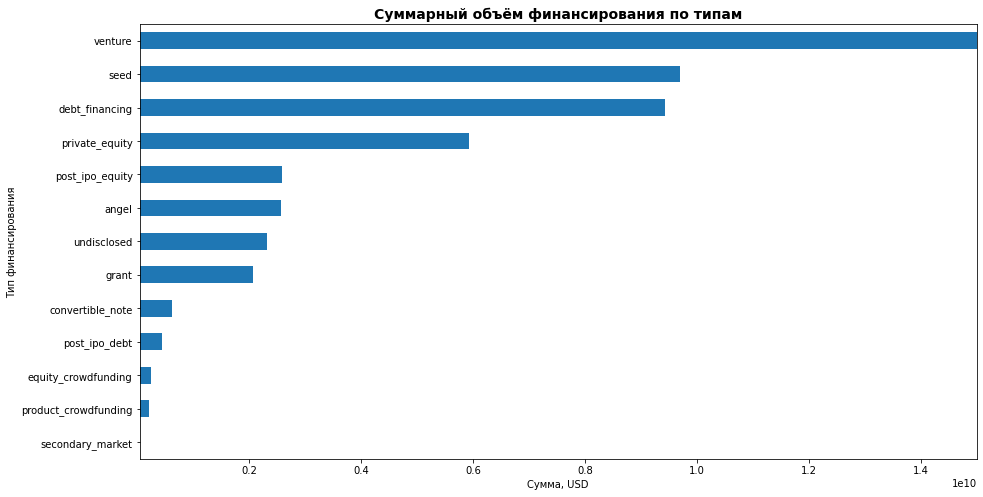

In [66]:
# Строим график. типы финансирования в сумме привлекли больше всего денег.
funding_sum.sort_values(ascending=True).plot(kind = 'barh')

plt.title('Суммарный объём финансирования по типам', fontsize=14, fontweight='bold')
plt.xlabel('Сумма, USD')
plt.ylabel('Тип финансирования')
plt.xlim(40000000,15000000000)
plt.show()

In [67]:
# Считаем количество по всем столбца типов финансирования
funding_count = (cb_investments[funding_types]>0).sum().sort_values(ascending=False)
# Выводим в читаемом формате 
funding_count.apply(lambda x: f'{x:,.0f}') 

venture                 19,514
seed                    13,456
debt_financing           3,375
angel                    2,970
grant                    1,013
undisclosed                830
private_equity             685
convertible_note           527
equity_crowdfunding        518
product_crowdfunding       207
post_ipo_equity            189
post_ipo_debt               33
secondary_market             7
dtype: object

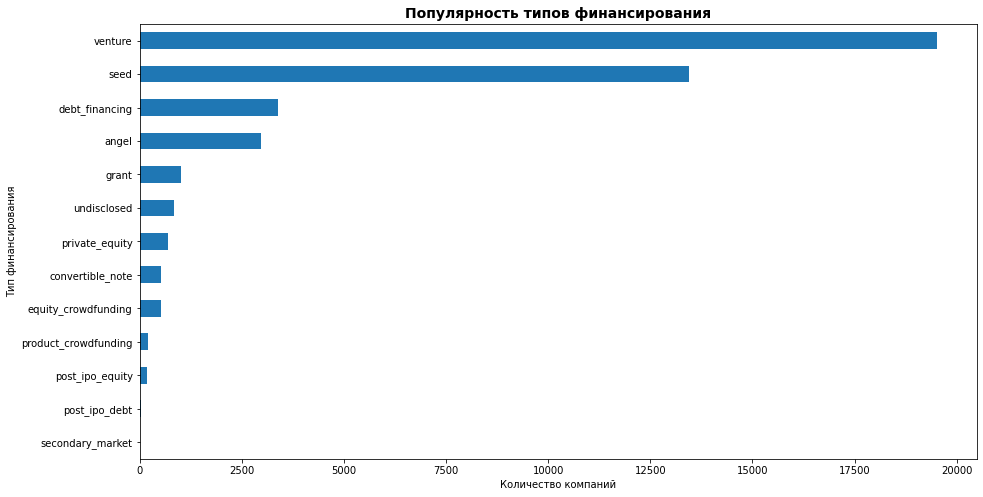

In [68]:
funding_count.sort_values(ascending=True).plot(kind = 'barh')

plt.title('Популярность типов финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')

plt.show()

**Вывод по сравнению графиков 'Суммарный объём финансирования по типам' и 'Популярность типов финансирования'**

Venture и seed доминируют как по объёму, так и по частоте использования, что подтверждает их ключевую роль в финансировании стартапов. Angel и grant также широко распространены, однако их суммарные объёмы уступают лидерам, что соответствует их функции на ранних стадиях. Private_equity и post_ipo_equity, напротив, встречаются реже, но обеспечивают значительные объёмы, что характерно для крупных сделок на поздних стадиях. Тип undisclosed сложно интерпретировать из-за отсутствия данных.

Строим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета `cb_returns`.

In [69]:
# Делаем сумирование возвратов от разных типов финансирования
funding_sum_returns = cb_returns[funding_types].sum().sort_values(ascending=False)
# Выводим 
funding_sum_returns

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

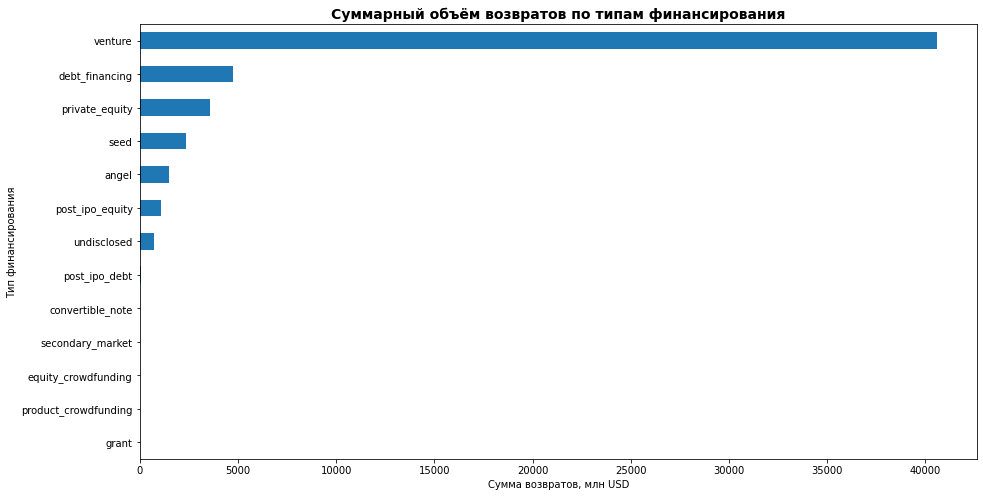

In [70]:
# Создаем график возвратов от разных типов финансирования 
funding_sum_returns.sort_values(ascending=True).plot(kind = 'barh')

plt.title('Суммарный объём возвратов по типам финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Сумма возвратов, млн USD')
plt.ylabel('Тип финансирования')

plt.show()

**Вывод по возвратам инвестиций**

Venture лидирует по объёму возвратов (40 578 млн USD), что соответствует его доминированию в инвестициях. Debt_financing, private_equity и seed также вносят значительный вклад. Нулевые возвраты по грантам ожидаемы, так как они предоставляются на безвозвратной основе. В целом структура возвратов повторяет структуру инвестиций, что подтверждает связь между объёмом вложений и объёмом возвратов

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

По столбцы `funding_total_usd` и `funding_rounds`, рассчитываем для каждой компании средний объём одного раунда финансирования.

Строим графики которые покажут:

* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


In [71]:
# Создаем столбец среднего объема одного раунда финансирования.
cb_investments['avg_round_size'] = cb_investments['funding_total_usd']/cb_investments['funding_rounds']

# Группмруем данные по 'funding_year'
rounds_agg =cb_investments.groupby('funding_year').agg({'avg_round_size':'median',
                                                        'funding_rounds':'sum'})
# Переводим размер раунда в миллионы долларов
rounds_agg['avg_round_size'] = rounds_agg['avg_round_size'] / 1000000

# Переименовываем столбцы
rounds_agg.columns = ['Медианный размер раунда, млн $','Количество раундов']

# Выводим результат таблицы
rounds_agg

,"Медианный размер раунда, млн $",Количество раундов
funding_year,,
2000,3.117500,137.0
2003,1.652194,140.0
2004,3.033333,188.0
2005,4.657750,1002.0
2006,4.000000,1975.0
2007,3.000000,3075.0
2008,2.470474,3903.0
2009,1.600000,4891.0
2010,1.347100,6507.0


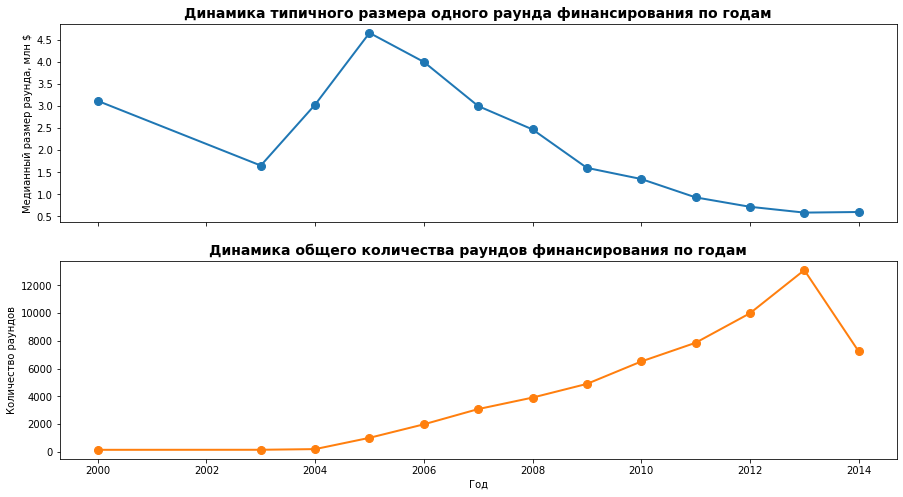

In [72]:
# Строим графики на одной оси координат Х
axes = rounds_agg.plot(kind = 'line',
                subplots = True, 
                sharex=True,
                sharey=False,
                marker='o',
                linewidth=2,
                markersize=8,
                legend =False)
# Заголовки
axes[0].set_title('Динамика типичного размера одного раунда финансирования по годам', fontsize=14, fontweight='bold')
axes[1].set_title('Динамика общего количества раундов финансирования по годам', fontsize=14, fontweight='bold')

# Подписи осей
axes[0].set_ylabel('Медианный размер раунда, млн $')
axes[1].set_ylabel('Количество раундов')
plt.xlabel('Год')

plt.show()
                

**Вывод по динамике предоставления финансирования по годам.**

Максимальный типичный размер раунда был в 2005 году - 4,500,000 USD.

Количество раундов - упало с 12,907 (в 2013) до 7,146 (падение на 45%)

Размер раунда — упал с 560,000 USD (в 2013) до ~574,000 USD, но при этом он вырос относительно 2013 года на 2.4%, хотя в целом тренд с 2011 года был понижательный.



### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составляем сводную таблицу в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отбираем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

Рассматриваем только массовые сегменты, а средние и нишевые исключаем.

Строим график как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам.

In [73]:
# Создаем сфводную таблицу в которой указывается суммарный размер общего финансирования
pivot_funding_total = pd.pivot_table(cb_investments, 
                                     index ='funding_year', 
                                     columns = 'market', 
                                     values = 'funding_total_usd',
                                     aggfunc = 'sum')
pivot_funding_total

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,Design,E-Commerce,Education,Enterprise Software,Entertainment,Fashion,Finance,Games,Hardware + Software,Health Care,Health and Wellness,Hospitality,Internet,Manufacturing,Marketplaces,Medical,Messaging,Mobile,Music,Networking,News,Nonprofits,Photography,Public Relations,Real Estate,SaaS,Search,Security,Semiconductors,Social Media,Social Network Media,Software,Software,Sports,Startups,Technology,Travel,Video,Web Hosting,E-Commerce,Mobile,No data,Software,Software,mid,niche
funding_year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,NaN,32879052.0,NaN,4.711445e+06,100000.0,NaN,15000000.0,43228774.0,NaN,1.600000e+07,11900000.0,NaN,10000000.0,56659310.0,NaN,24000000.0,21350000.0,1.000000e+07,NaN,NaN,NaN,6500000.0,NaN,NaN,2500000.0,NaN,16001000.0,5211700.0,NaN,NaN,NaN,NaN,3.173264e+07,NaN,NaN,NaN,50230.0,NaN,95343090.0,NaN,NaN,1839560.0,NaN,NaN,1.452904e+08,4.360000e+07
2003,NaN,NaN,NaN,4530000.0,NaN,6.631168e+07,5.035294e+07,NaN,NaN,13550000.0,NaN,NaN,2500000.0,7.669661e+06,NaN,9800000.0,25320000.0,11348830.0,12200000.0,NaN,3414041.0,NaN,NaN,4269608.0,NaN,NaN,NaN,2.801006e+07,NaN,NaN,1000000.0,NaN,7100000.0,NaN,6292200.0,NaN,5000000.0,51319746.0,2.800000e+07,NaN,NaN,25000.0,3.917820e+07,NaN,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN,4155202.0,NaN,26382837.0,8.349340e+07,3.355949e+07
2004,36000000.0,3000000.0,NaN,NaN,NaN,9.718486e+07,NaN,NaN,NaN,40350000.0,NaN,1505741.0,1350000.0,4.500000e+06,NaN,NaN,NaN,38150000.0,14775000.0,1.027591e+08,NaN,NaN,10500000.0,3000000.0,NaN,NaN,200000.0,5.346623e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10800000.0,73200000.0,8.878280e+07,6850000.0,NaN,NaN,1.405738e+08,NaN,NaN,1750000.0,10230000.0,14704000.0,16000000.0,NaN,16355899.0,10847977.0,NaN,NaN,8.878816e+07,4.602795e+07
2005,104596022.0,67857500.0,NaN,78782576.0,NaN,4.776736e+08,1.942000e+07,NaN,42862000.0,53450000.0,NaN,8568620.0,19751000.0,3.364635e+08,10000000.0,NaN,48235001.0,75866921.0,299216037.0,1.110914e+08,30210000.0,1020480.0,1775000.0,61770000.0,NaN,11090000.0,154917020.0,2.257094e+08,9970000.0,NaN,9590000.0,17051520.0,7000000.0,79695875.0,250000.0,5240000.0,11200000.0,327959701.0,6.632208e+08,22760000.0,1800000.0,9473280.0,1.085399e+09,1882200.0,NaN,50728425.0,27830000.0,5000000.0,483332632.0,NaN,4868970.0,28384331.0,12960000.0,86330000.0,2.923982e+08,1.024106e+08
2006,284953208.0,171701311.0,1310600.0,37660000.0,NaN,1.188979e+09,1.314739e+08,9666354.0,23965548.0,155788683.0,707000.0,125696810.0,21511823.0,8.072262e+08,21800000.0,2620000.0,178739768.0,251459860.0,359104024.0,6.230567e+08,43270000.0,14655808.0,5000.0,198957786.0,NaN,20250000.0,145133772.0,4.219073e+08,56466885.0,26889850.0,52116568.0,10080000.0,17936406.0,60450000.0,2080000.0,4791121.0,66056262.0,242063300.0,1.472019e+09,62169880.0,5245100.0,NaN,1.727667e+09,7000000.0,NaN,89983715.0,11700000.0,55321772.0,716959267.0,1120000.0,5089961.0,46049840.0,14990000.0,54500000.0,6.177852e+08,2.029424e+08
2007,791668713.0,129329000.0,NaN,37612601.0,7780000.0,2.055431e+09,7.268772e+08,47345733.0,83846345.0,305477517.0,10800000.0,83632386.0,42783001.0,1.015740e+09,31224025.0,24100000.0,407216739.0,524856628.0,567251382.0,7.580546e+08,57328401.0,13547173.0,4455379.0,121700544.0,3885720.0,2100000.0,67516299.0,5.653268e+08,61033838.0,43745721.0,75941043.0,200000.0,21315000.0,23010000.0,33210000.0,14652595.0,100174551.0,388390423.0,1.774714e+09,78126221.0,23504021.0,61950000.0,1.600385e+09,28651580.0,NaN,249617003.0,29481724.0,94730644.0,423521449.0,NaN,17877080.0,35532468.0,73617182.0,65133032.0,8.805161e+08,4.205866e+08
2008,694249546.0,207645600.0,4300000.0,58870829.0,2452515.0,1.936542e+09,3.280224e+09,44375000.0,18361080.0,330829503.0,5944302.0,221331058.0,89733027.0,9.337489e+08,28600000.0,34221883.0,309395927.0,487915311.0,377220367.0,1.167266e+09,17467779.0,6544195.0,21412964.0,173054

In [74]:
# Заносим в перемнные строки так год это индекс
row_2013 = pivot_funding_total.loc[2013]
row_2014 = pivot_funding_total.loc[2014]
# Создаем логическое условие которое создает True или False
expression = row_2014 > row_2013
# Оставляем только True  и делаем список
expression = expression[expression == True].index.tolist()
# Делаем фильтрацию колонок
pivot_funding_total_if = pivot_funding_total[expression]
pivot_funding_total_if

market,Apps,Entertainment,Internet,Medical,Messaging,Photography,Real Estate,Sports,Startups,Technology,Video,No data,Software,niche
funding_year,,,,,,,,,,,,,,
2000,NaN,100000.0,10000000.0,24000000.0,21350000.0,NaN,2500000.0,NaN,NaN,NaN,NaN,1839560.0,NaN,4.360000e+07
2003,NaN,NaN,NaN,NaN,NaN,7100000.0,6292200.0,NaN,NaN,NaN,5000000.0,4155202.0,NaN,3.355949e+07
2004,NaN,NaN,10500000.0,NaN,200000.0,NaN,NaN,NaN,NaN,1750000.0,14704000.0,10847977.0,NaN,4.602795e+07
2005,NaN,10000000.0,1775000.0,11090000.0,154917020.0,7000000.0,250000.0,1882200.0,NaN,50728425.0,5000000.0,28384331.0,12960000.0,1.024106e+08
2006,1310600.0,21800000.0,5000.0,20250000.0,145133772.0,17936406.0,2080000.0,7000000.0,NaN,89983715.0,55321772.0,46049840.0,14990000.0,2.029424e+08
2007,NaN,31224025.0,4455379.0,2100000.0,67516299.0,21315000.0,33210000.0,28651580.0,NaN,249617003.0,94730644.0,35532468.0,73617182.0,4.205866e+08
2008,4300000.0,28600000.0,21412964.0,28812744.0,64954600.0,28949322.0,46613100.0,16740290.0,5010387.0,338226238.0,37865177.0,69575010.0,72595652.0,3.534489e+08
2009,9505842.0,11069585.0,29745773.0,11566200.0,65027748.0,35275864.0,25452840.0,7946511.0,460700.0,103078850.0,63955584.0,197066716.0,124864517.0,4.666513e+08
2010,6123779.0,17197608.0,36157500.0,52540338.0,55396260.0,27897484.0,35619608.0,32884989.0,2111966.0,272476805.0,104083703.0,194832738.0,96891667.0,6.024675e+08


<Figure size 864x576 with 0 Axes>

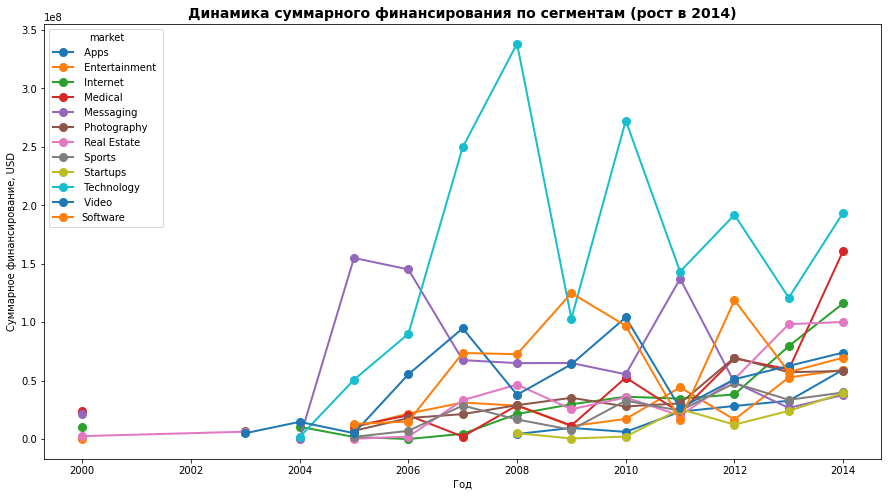

In [75]:
# Удоляем нишевые и так же No data, средние не вошли. Оставляем только массовые.
plt.figure(figsize=(12, 8))
# Создаем график
pivot_filtered = pivot_funding_total_if.drop(columns=['No data','niche'])
pivot_filtered.plot(kind = 'line',
                             marker='o',
                             linewidth=2,
                             markersize=8)
# Добавляем параметры
plt.title('Динамика суммарного финансирования по сегментам (рост в 2014)', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, USD')
plt.show()

**Вывод по динамике размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов**

Анализ динамики суммарного финансирования позволяет выделить несколько групп сегментов по характеру роста:

Technology — лидирует по абсолютному объёму финансирования, демонстрирует резкий рост, однако его динамика отличается высокой волатильностью, что делает его перспективным, но рискованным для долгосрочных прогнозов.

Medical — показывает устойчивый и стремительный рост, при этом динамика сегмента стабильна, без значительных колебаний, что говорит о его надёжности и привлекательности для инвесторов.

Internet — схож с Medical по характеру роста: стабильная положительная динамика без резких спадов, что подтверждает его статус одного из наиболее уверенно растущих сегментов.

Real Estate — демонстрирует умеренный, но стабильный рост, особенно заметный в сравнении с 2013 годом, что указывает на постепенное восстановление интереса к этому сегменту.

Apps — показывает невысокие темпы роста относительно 2013 года, однако динамика достаточно стабильная, без резких провалов, что позволяет рассматривать его как перспективный в долгосрочной перспективе.

Startups — объёмы финансирования невелики, но сегмент демонстрирует плавный и уверенный рост, что может свидетельствовать о формировании нового направления, заслуживающего внимания."

Таким образом, наиболее сбалансированным по сочетанию роста и стабильности выглядят сегменты Medical и Internet. Для агрессивных инвестиционных стратегий интерес может представлять Technology с его высокими объёмами и потенциалом, но с учётом повышенной волатильности.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования


Определяем для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных.

Аномальные значения меняем на пропуски.

Что бы не делить на ноль добавляем число к знаменателю `1e-60`.

In [76]:
# Группируем и считаем сумму в каждом типе
invest = cb_investments.groupby('funding_year')[funding_types].sum()
invest

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
funding_year,,,,,,,,,,,,,
2000,1.675914e+07,3.614622e+08,0.0,210402640.0,0.0,1.400000e+07,26086333.0,293114.0,0.000000e+00,3.467747e+06,0.0,7718867.0,0.0
2003,1.531836e+07,4.577844e+08,0.0,10280000.0,0.0,3.050000e+06,5629661.0,16850717.0,2.086975e+07,0.000000e+00,0.0,0.0,0.0
2004,1.810473e+07,8.004405e+08,0.0,62912359.0,0.0,2.881662e+07,11013741.0,10363600.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0
2005,3.942520e+07,5.324976e+09,0.0,27462243.0,0.0,1.162207e+08,62914621.0,6266481.0,5.000000e+06,4.796022e+06,0.0,0.0,0.0
2006,7.582683e+07,1.029954e+10,933057.0,61545498.0,10702385.0,1.848965e+08,71956153.0,6147500.0,1.215159e+08,3.800708e+07,0.0,0.0,0.0
2007,2.170864e+08,1.397983e+10,0.0,158589321.0,14116788.0,3.033700e+08,215652441.0,52493300.0,1.533702e+08,1.200000e+07,0.0,0.0,0.0
2008,3.124030e+08,1.647468e+10,0.0,127738738.0,28750902.0,4.641707e+08,249799613.0,23485347.0,2.115826e+08,3.600000e+07,0.0,0.0,1000000.0
2009,2.888473e+08,1.719199e+10,2049671.0,143087655.0,80237381.0,1.128830e+09,169589726.0,235191752.0,3.603696e+08,9.358240e+07,90750.0,19300000.0,303050.0
2010,5.482233e+08,1.955812e+10,8148000.0,252877259.0,51782821.0,1.301615e+09,246516518.0,243645678.0,7.179203e+08,2.933760e+08,30000000.0,910000.0,3500000.0


In [77]:
# Объеденяем таблицы  'invest' и 'cb_returns'
merged = invest.join(cb_returns, how='inner', lsuffix='_invest', rsuffix='_return')
merged

,seed_invest,venture_invest,equity_crowdfunding_invest,undisclosed_invest,convertible_note_invest,debt_financing_invest,angel_invest,grant_invest,private_equity_invest,post_ipo_equity_invest,post_ipo_debt_invest,secondary_market_invest,product_crowdfunding_invest,seed_return,venture_return,equity_crowdfunding_return,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return
2000,1.675914e+07,3.614622e+08,0.0,210402640.0,0.0,1.400000e+07,26086333.0,293114.0,0.000000e+00,3.467747e+06,0.0,7718867.0,0.0,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2003,1.531836e+07,4.577844e+08,0.0,10280000.0,0.0,3.050000e+06,5629661.0,16850717.0,2.086975e+07,0.000000e+00,0.0,0.0,0.0,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,1.810473e+07,8.004405e+08,0.0,62912359.0,0.0,2.881662e+07,11013741.0,10363600.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,3.942520e+07,5.324976e+09,0.0,27462243.0,0.0,1.162207e+08,62914621.0,6266481.0,5.000000e+06,4.796022e+06,0.0,0.0,0.0,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,7.582683e+07,1.029954e+10,933057.0,61545498.0,10702385.0,1.848965e+08,71956153.0,6147500.0,1.215159e+08,3.800708e+07,0.0,0.0,0.0,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,2.170864e+08,1.397983e+10,0.0,158589321.0,14116788.0,3.033700e+08,215652441.0,52493300.0,1.533702e+08,1.200000e+07,0.0,0.0,0.0,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,3.124030e+08,1.647468e+10,0.0,127738738.0,28750902.0,4.641707e+08,249799613.0,23485347.0,2.115826e+08,3.600000e+07,0.0,0.0,1000000.0,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
2009,2.888473e+08,1.719199e+10,2049671.0,143087655.0,80237381.0,1.128830e+09,169589726.0,235191752.0,3.603696e+08,9.358240e+07,90750.0,19300000.0,303050.0,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02
2010,5.482233e+08,1.955812e+10,8148000.0,252877259.0,51782821.0,1.301615e+09,246516518.0,243645678.0,7.179203e+08,2.933760e+08,30000000.0,910000.0,3500000.0,265.33,3299.35,0.39,52.15,3.14,503.73,157.21,0.0,339.08,115.72,0.00,0.18,0.24
2011,1.183121e+09,1.760987e+10,3091684.0,283560865.0,82113209.0,1.234582e+09,402074405.0,253421367.0,1.069066e+09,1.933984e+08,3100000.0,12500000.0,18142441.0,317.29,3919.38,0.30,59.36,3.96,572.92,172.17,0.0,666.03,129.01,3.04,0.16,0.26


In [78]:
# Делаем вычесление доли и формируем новые колонки 
for col in funding_types:
    # Формируем названия колонок
    return_col = col + '_return'
    invest_col = col + '_invest'
    ratio_col = col + '_ratio'
    # Считаем долю возврата
    merged[ratio_col] = merged[return_col]/(merged[invest_col] + 1e-60)
# Выводим таблицу    
merged

,seed_invest,venture_invest,equity_crowdfunding_invest,undisclosed_invest,convertible_note_invest,debt_financing_invest,angel_invest,grant_invest,private_equity_invest,post_ipo_equity_invest,post_ipo_debt_invest,secondary_market_invest,product_crowdfunding_invest,seed_return,venture_return,equity_crowdfunding_return,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return,seed_ratio,venture_ratio,equity_crowdfunding_ratio,undisclosed_ratio,convertible_note_ratio,debt_financing_ratio,angel_ratio,grant_ratio,private_equity_ratio,post_ipo_equity_ratio,post_ipo_debt_ratio,secondary_market_ratio,product_crowdfunding_ratio
2000,1.675914e+07,3.614622e+08,0.0,210402640.0,0.0,1.400000e+07,26086333.0,293114.0,0.000000e+00,3.467747e+06,0.0,7718867.0,0.0,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00,9.964712e-07,1.532664e-07,0.000000e+00,3.717159e-07,0.000000e+00,6.185714e-07,2.464892e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2003,1.531836e+07,4.577844e+08,0.0,10280000.0,0.0,3.050000e+06,5629661.0,16850717.0,2.086975e+07,0.000000e+00,0.0,0.0,0.0,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00,5.052762e-07,5.108518e-07,0.000000e+00,9.143969e-07,1.000000e+58,3.573770e-07,6.057203e-07,0.0,7.762433e-08,2.110000e+60,0.000000e+00,8.000000e+58,0.000000e+00
2004,1.810473e+07,8.004405e+08,0.0,62912359.0,0.0,2.881662e+07,11013741.0,10363600.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00,5.484755e-07,6.944926e-07,0.000000e+00,5.275593e-07,1.000000e+58,4.702147e-07,8.335043e-07,0.0,2.190000e+60,3.380000e+60,0.000000e+00,5.500000e+59,0.000000e+00
2005,3.942520e+07,5.324976e+09,0.0,27462243.0,0.0,1.162207e+08,62914621.0,6266481.0,5.000000e+06,4.796022e+06,0.0,0.0,0.0,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00,6.746954e-07,4.936961e-07,0.000000e+00,3.462936e-07,2.000000e+58,3.019257e-07,4.936849e-07,0.0,4.800000e-07,7.318565e-07,0.000000e+00,5.000000e+58,0.000000e+00
2006,7.582683e+07,1.029954e+10,933057.0,61545498.0,10702385.0,1.848965e+08,71956153.0,6147500.0,1.215159e+08,3.800708e+07,0.0,0.0,0.0,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00,8.151468e-07,3.010017e-07,2.036317e-07,7.594382e-07,1.663181e-07,6.122884e-07,6.635986e-07,0.0,1.371837e-07,5.414781e-07,0.000000e+00,1.200000e+59,0.000000e+00
2007,2.170864e+08,1.397983e+10,0.0,158589321.0,14116788.0,3.033700e+08,215652441.0,52493300.0,1.533702e+08,1.200000e+07,0.0,0.0,0.0,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00,3.243409e-07,2.564674e-07,1.000000e+58,3.491408e-07,2.280972e-07,4.142797e-07,7.628478e-07,0.0,5.790563e-07,2.030000e-06,0.000000e+00,5.700000e+59,0.000000e+00
2008,3.124030e+08,1.647468e+10,0.0,127738738.0,28750902.0,4.641707e+08,249799613.0,23485347.0,2.115826e+08,3.600000e+07,0.0,0.0,1000000.0,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00,2.871931e-07,1.649209e-07,3.000000e+58,3.211242e-07,5.947639e-08,8.564522e-07,4.116500e-07,0.0,6.162132e-07,2.341111e-06,0.000000e+00,4.700000e+59,0.000000e+00
2009,2.888473e+08,1.719199e+10,2049671.0,143087655.0,80237381.0,1.128830e+09,169589726.0,235191752.0,3.603696e+08,9.358240e+07,90750.0,19300000.0,303050.0,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02,5.546528e-07,1.454916e-07,8.781897e-08,2.620771e-07,2.804179e-08,3.491224e-07,5.732069e-07,0.0,5.652531e-07,8.202397e-07,0.000000e+00,6.217617e-09,6.599571e-08
2010,5.482233e+08,1.955812e+10,8148000.0,252877259.0,51782821.0,1.301615e+09,246516518.0,243645678.0,7.179203e+08,2.933760e+08,30000000.0,910000.0,3500000.0,265.33,3299.35,0.39,52.15,3.14,503.73,157.21,0.0,339.08,115.72,0.00,0.18,0.24,4.839816e-07,1.686946e-07,4.786451e-08,2.062265e-07,6.063787e-08,3.870038e-07,6.37

In [79]:
# Заменяем выбросы на Nan

# Создаем генератор списка 
ratio_cols = [col for col in merged.columns if col.endswith('_ratio')]

# Применяем IQR через loc
for col in ratio_cols:
    q1 = merged[col].quantile(0.25)
    q3 = merged[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    
    # Заменяем выбросы на NaN через loc
    merged.loc[merged[col] > upper, col] = None
# Выводим таблицу
merged[ratio_cols]

,seed_ratio,venture_ratio,equity_crowdfunding_ratio,undisclosed_ratio,convertible_note_ratio,debt_financing_ratio,angel_ratio,grant_ratio,private_equity_ratio,post_ipo_equity_ratio,post_ipo_debt_ratio,secondary_market_ratio,product_crowdfunding_ratio
2000,NaN,1.532664e-07,0.000000e+00,3.717159e-07,0.000000e+00,6.185714e-07,2.464892e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2003,5.052762e-07,5.108518e-07,0.000000e+00,NaN,NaN,3.573770e-07,6.057203e-07,0.0,7.762433e-08,NaN,0.000000e+00,8.000000e+58,0.000000e+00
2004,5.484755e-07,6.944926e-07,0.000000e+00,5.275593e-07,NaN,4.702147e-07,8.335043e-07,0.0,NaN,NaN,0.000000e+00,5.500000e+59,0.000000e+00
2005,6.746954e-07,4.936961e-07,0.000000e+00,3.462936e-07,NaN,3.019257e-07,4.936849e-07,0.0,4.800000e-07,7.318565e-07,0.000000e+00,5.000000e+58,0.000000e+00
2006,8.151468e-07,3.010017e-07,2.036317e-07,7.594382e-07,1.663181e-07,6.122884e-07,6.635986e-07,0.0,1.371837e-07,5.414781e-07,0.000000e+00,1.200000e+59,0.000000e+00
2007,3.243409e-07,2.564674e-07,NaN,3.491408e-07,2.280972e-07,4.142797e-07,7.628478e-07,0.0,5.790563e-07,2.030000e-06,0.000000e+00,5.700000e+59,0.000000e+00
2008,2.871931e-07,1.649209e-07,NaN,3.211242e-07,5.947639e-08,8.564522e-07,4.116500e-07,0.0,6.162132e-07,2.341111e-06,0.000000e+00,4.700000e+59,0.000000e+00
2009,5.546528e-07,1.454916e-07,8.781897e-08,2.620771e-07,2.804179e-08,3.491224e-07,5.732069e-07,0.0,5.652531e-07,8.202397e-07,0.000000e+00,6.217617e-09,NaN
2010,4.839816e-07,1.686946e-07,4.786451e-08,2.062265e-07,6.063787e-08,3.870038e-07,6.377260e-07,0.0,4.723087e-07,3.944426e-07,0.000000e+00,1.978022e-07,NaN
2011,2.681804e-07,2.225672e-07,9.703450e-08,2.093378e-07,4.822610e-08,4.640600e-07,4.282043e-07,0.0,6.230018e-07,6.670686e-07,NaN,1.280000e-08,1.433104e-08


Строим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

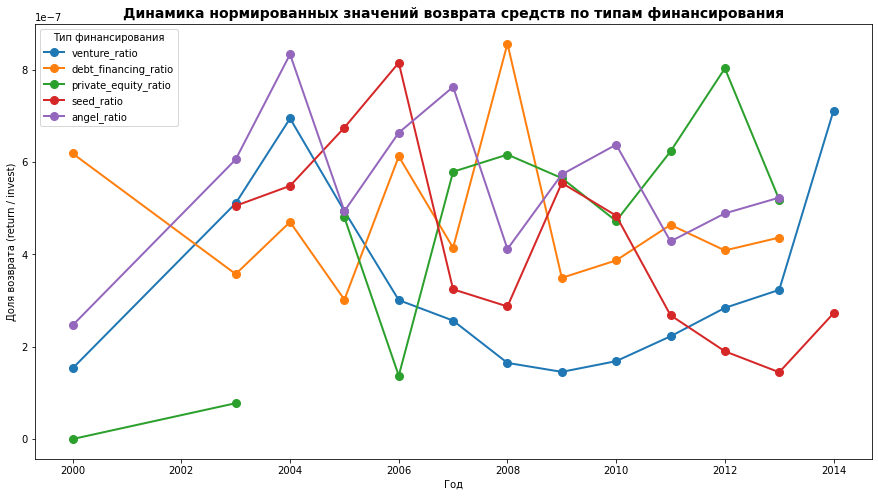

In [80]:
# Создаем график нормированные значения возврата средств для типов финансирования
types_ratio = ['venture_ratio', 'debt_financing_ratio', 'private_equity_ratio', 'seed_ratio', 'angel_ratio']

merged[types_ratio].plot(kind = 'line',
                             marker='o',
                             linewidth=2,
                             markersize=8)
plt.title('Динамика нормированных значений возврата средств по типам финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Доля возврата (return / invest)')
plt.legend(title='Тип финансирования')
plt.show()

**Вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя**

Анализ показал, что наиболее устойчивый рост показателя возврата средств наблюдается у типа финансирования `private_equity`. Несмотря на отдельные колебания, его значения постепенно увеличиваются, а к 2014 году достигают максимального уровня среди всех рассмотренных типов финансирования. Тип `debt_financing` также демонстрирует положительную динамику, однако характеризуется более резкими изменениями показателя. Для venture наблюдается восстановление после периода снижения, тогда как `seed` и `angel` не показывают устойчивой положительной тенденции.


## Шаг 5. Итоговый вывод и рекомендации


В ходе исследования была проведена предобработка данных: обработаны пропущенные значения, устранены дубликаты, приведены типы данных, а также сформированы новые признаки для последующего анализа. Дополнительно были объединены нишевые и средние сегменты рынка, что позволило сократить количество категорий и сделать дальнейшее исследование более наглядным.

В процессе анализа были исследованы сроки финансирования компаний, распределение объёма привлечённых инвестиций, структура рынка по сегментам, выявлены компании с аномальным объёмом финансирования с использованием метода `IQR`, а также проанализированы основные типы финансирования и их динамика по годам.

Полученные результаты показывают, что наибольшая часть компаний относится к нишевым сегментам рынка, при этом основной объём инвестиций сосредоточен у компаний, которые привлекали финансирование на протяжении нескольких лет. Анализ распределения финансирования также показал наличие небольшого числа компаний с очень крупными объёмами инвестиций, существенно превышающими типичные значения для своих сегментов.

Исследование динамики финансирования по отраслям показало, что наиболее устойчивый рост объёма привлечённых средств к 2015 году демонстрирует отрасль `Medical`. Среди типов финансирования наиболее перспективным выглядит `private equity`, поскольку именно этот тип показывает наиболее устойчивый рост показателя возврата средств к концу рассматриваемого периода. Следовательно, при принятии инвестиционного решения в 2015 году можно рекомендовать рассмотреть инвестиции в компании отрасли `Medical` с использованием механизма `private equity`.

В целом результаты всех этапов исследования хорошо согласуются между собой. Анализ структуры рынка, объёмов финансирования, выявление аномальных компаний и исследование динамики различных типов финансирования формируют единую картину рынка и позволяют сделать обоснованные рекомендации для потенциального инвестора. При этом необходимо учитывать, что выводы основаны на исторических данных до 2015 года и отражают ситуацию только за рассматриваемый период.